# Semantic Plagiarism Engine — Results Dashboard
**Authors:** Arian Jafari · Mehrnia Amouei

---
| Section | Content |
|---|---|
| 1 | Two-File Comparison |
| 2 | Corpus Scan |
| 3 | Dataset Evaluation — Metrics Summary |
| 4 | Score Distributions |
| 5 | Confusion Matrices |
| 6 | Method Comparison Chart |


## Setup

In [1]:
import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", None)

OUTPUTS = Path("../outputs")

# ── Shared table style ────────────────────────────────────────────────────────
TABLE_STYLES = [
    {"selector": "caption",
     "props": [("font-size", "15px"), ("font-weight", "bold"),
               ("color", "#1a252f"), ("padding", "8px 0 6px 0"),
               ("text-align", "left"), ("caption-side", "top")]},
    {"selector": "th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("font-weight", "bold"), ("padding", "10px 18px"),
               ("text-align", "center"), ("border", "1px solid #ddd")]},
    {"selector": "td",
     "props": [("padding", "8px 16px"), ("text-align", "center"),
               ("border", "1px solid #eee")]},
    {"selector": "tr:nth-child(even)",
     "props": [("background-color", "#f7f9fc")]},
    {"selector": "tr:hover",
     "props": [("background-color", "#eaf4fb")]},
    {"selector": "",
     "props": [("border-collapse", "collapse"), ("min-width", "480px")]},
]

def show(df, caption="", gradient_cols=None, fmt=None, bar_cols=None):
    s = df.style.set_caption(caption).set_table_styles(TABLE_STYLES)
    if fmt:
        s = s.format(fmt)
    if gradient_cols:
        s = s.background_gradient(subset=gradient_cols, cmap="YlGn")
    if bar_cols:
        s = s.bar(subset=bar_cols, color="#a8d5ba", vmin=0, vmax=1)
    return s

print("✓  Setup complete")


✓  Setup complete


---
## 1 · Two-File Comparison
Three metrics applied to a near-duplicate pair and an unrelated pair.

In [2]:
with open(OUTPUTS / "two_file_compare.json") as f:
    near = json.load(f)
with open(OUTPUTS / "two_file_compare_unrelated.json") as f:
    unrel = json.load(f)

METRIC_KEYS  = ["jaccard", "minhash", "simhash_similarity",
                "simhash_hamming_distance", "shingles_a", "shingles_b",
                "tokens_a", "tokens_b"]
METRIC_LABELS = ["Jaccard similarity", "MinHash estimate",
                 "SimHash similarity", "Hamming distance",
                 "Shingles (doc A)", "Shingles (doc B)",
                 "Tokens (doc A)",   "Tokens (doc B)"]

df_cmp = pd.DataFrame({
    "Metric":                        METRIC_LABELS,
    "Near-duplicate  (doc_01 ↔ doc_02)": [near[k]  for k in METRIC_KEYS],
    "Unrelated  (doc_01 ↔ doc_05)":      [unrel[k] for k in METRIC_KEYS],
})

show(df_cmp,
     caption="Two-File Comparison — All Metrics",
     fmt={"Near-duplicate  (doc_01 ↔ doc_02)": "{:.4f}",
          "Unrelated  (doc_01 ↔ doc_05)": "{:.4f}"})


,Metric,Near-duplicate (doc_01 ↔ doc_02),Unrelated (doc_01 ↔ doc_05)
0,Jaccard similarity,0.5625,0.0000
1,MinHash estimate,0.6016,0.0000
2,SimHash similarity,0.8438,0.5312
3,Hamming distance,10.0000,30.0000
4,Shingles (doc A),124.0000,124.0000
5,Shingles (doc B),126.0000,132.0000
6,Tokens (doc A),126.0000,126.0000
7,Tokens (doc B),128.0000,134.0000


---
## 2 · Corpus Scan
Brute-force scan of 5 sample documents (threshold = 0.15). Only the two true near-duplicate pairs surfaced — zero false positives.

In [3]:
df_cand = pd.read_csv(OUTPUTS / "candidates.csv")
df_cand["jaccard"] = df_cand["jaccard"].astype(float)
df_cand["minhash"] = df_cand["minhash"].astype(float)

show(df_cand,
     caption="Corpus Scan — Detected Near-Duplicate Pairs",
     gradient_cols=["jaccard", "minhash"],
     fmt={"jaccard": "{:.4f}", "minhash": "{:.4f}"})


,doc_a,doc_b,jaccard,minhash
0,doc_01.txt,doc_02.txt,0.5625,0.6016
1,doc_03.txt,doc_04.txt,0.5195,0.5625


---
## 3 · Dataset Evaluation — Metrics Summary
5,000 Quora question pairs · ~38 % duplicates  
Thresholds: Jaccard = 0.10 · MinHash = 0.10 · SimHash = 0.75

In [4]:
frames = []
for method in ("jaccard", "minhash", "simhash"):
    frames.append(pd.read_csv(OUTPUTS / f"metrics_{method}.csv"))

df_metrics = pd.concat(frames, ignore_index=True)

KEEP = ["method", "threshold", "seconds",
        "precision", "recall", "f1", "accuracy",
        "true_positive", "false_positive", "true_negative", "false_negative"]
RENAME = {
    "method": "Method", "threshold": "Threshold", "seconds": "Time (s)",
    "precision": "Precision", "recall": "Recall", "f1": "F1",
    "accuracy": "Accuracy",
    "true_positive": "TP", "false_positive": "FP",
    "true_negative": "TN", "false_negative": "FN",
}

df_show = df_metrics[KEEP].rename(columns=RENAME)
df_show["Method"] = df_show["Method"].str.capitalize()

FMT = {c: "{:.4f}" for c in ["Precision", "Recall", "F1", "Accuracy", "Time (s)"]}

show(df_show,
     caption="Evaluation Metrics — Quora Question Pairs (5 000 pairs)",
     gradient_cols=["F1", "Accuracy"],
     fmt=FMT)


,Method,Threshold,Time (s),Precision,Recall,F1,Accuracy,TP,FP,TN,FN
0,Jaccard,0.100000,0.1469,0.5543,0.4268,0.4823,0.6496,816,656,2432,1096
1,Minhash,0.100000,2.3263,0.5526,0.4090,0.4701,0.6474,782,633,2455,1130
2,Simhash,0.750000,0.9827,0.5709,0.4336,0.4929,0.6588,829,623,2465,1083


---
## 4 · Score Distributions
Mean similarity scores for true-duplicate vs non-duplicate pairs, per method.

In [5]:
rows = []
for method in ("jaccard", "minhash", "simhash"):
    df = pd.read_csv(OUTPUTS / f"predictions_{method}.csv")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    dup  = df[df["label"] == 1]["score"]
    ndup = df[df["label"] == 0]["score"]
    rows.append({
        "Method":              method.capitalize(),
        "Dup — Mean":          dup.mean(),
        "Dup — Std":           dup.std(),
        "Non-dup — Mean":      ndup.mean(),
        "Non-dup — Std":       ndup.std(),
        "Separation  (Δ mean)": dup.mean() - ndup.mean(),
    })

df_dist = pd.DataFrame(rows)

show(df_dist,
     caption="Score Statistics: Duplicate vs Non-Duplicate Pairs",
     gradient_cols=["Separation  (Δ mean)"],
     fmt={c: "{:.4f}" for c in df_dist.columns if c != "Method"})


,Method,Dup — Mean,Dup — Std,Non-dup — Mean,Non-dup — Std,Separation (Δ mean)
0,Jaccard,0.1484,0.2307,0.0822,0.1884,0.0663
1,Minhash,0.1478,0.2322,0.0824,0.1903,0.0655
2,Simhash,0.7296,0.1166,0.6357,0.1216,0.0939


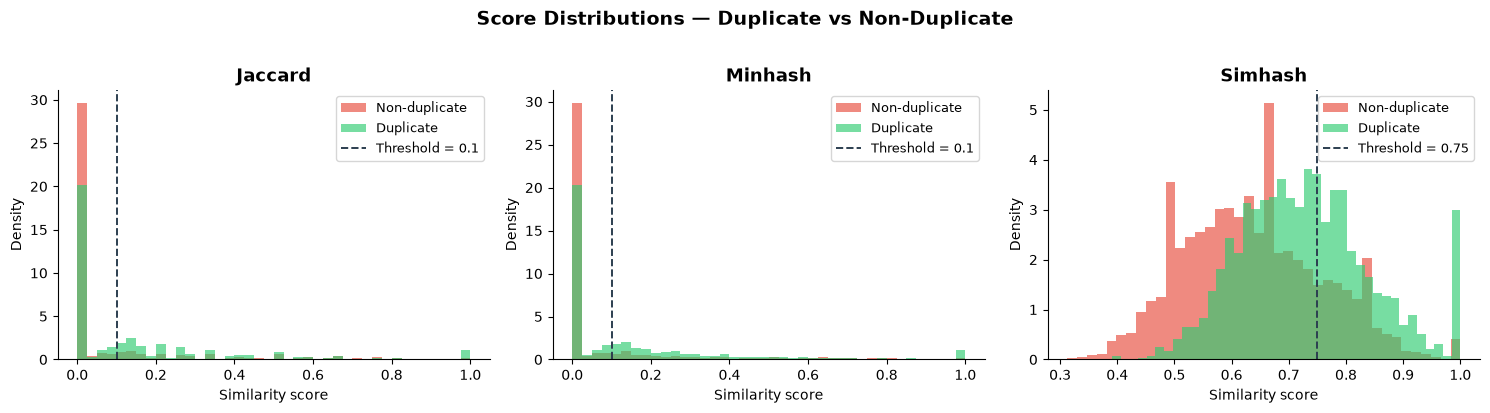

✓  Saved → outputs/score_distributions.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("Score Distributions — Duplicate vs Non-Duplicate", fontsize=14, fontweight="bold", y=1.02)

COLORS = {"Duplicate": "#2ecc71", "Non-duplicate": "#e74c3c"}
METHODS = ["jaccard", "minhash", "simhash"]
THRESHOLDS = {"jaccard": 0.10, "minhash": 0.10, "simhash": 0.75}

for ax, method in zip(axes, METHODS):
    df = pd.read_csv(OUTPUTS / f"predictions_{method}.csv")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df["label"] = pd.to_numeric(df["label"], errors="coerce")

    dup  = df[df["label"] == 1]["score"].dropna()
    ndup = df[df["label"] == 0]["score"].dropna()

    ax.hist(ndup, bins=40, alpha=0.65, color=COLORS["Non-duplicate"],
            label="Non-duplicate", density=True)
    ax.hist(dup,  bins=40, alpha=0.65, color=COLORS["Duplicate"],
            label="Duplicate",     density=True)

    thr = THRESHOLDS[method]
    ax.axvline(thr, color="#2c3e50", linestyle="--", linewidth=1.4,
               label=f"Threshold = {thr}")

    ax.set_title(method.capitalize(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Similarity score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved → outputs/score_distributions.png")


---
## 5 · Confusion Matrices

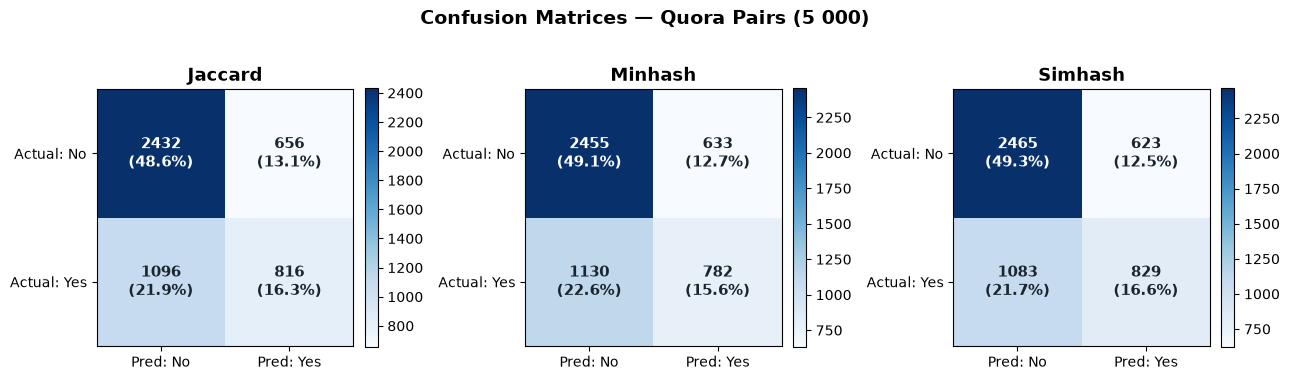

✓  Saved → outputs/confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Confusion Matrices — Quora Pairs (5 000)", fontsize=14, fontweight="bold")

for ax, method in zip(axes, METHODS):
    row = df_metrics[df_metrics["method"] == method].iloc[0]
    cm = [[int(row["true_negative"]),  int(row["false_positive"])],
          [int(row["false_negative"]), int(row["true_positive"])]]

    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: No", "Pred: Yes"], fontsize=10)
    ax.set_yticklabels(["Actual: No", "Actual: Yes"], fontsize=10)
    ax.set_title(method.capitalize(), fontsize=13, fontweight="bold")

    total = sum(v for row_ in cm for v in row_)
    for r in range(2):
        for c in range(2):
            val = cm[r][c]
            pct = val / total * 100
            ax.text(c, r, f"{val}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=11,
                    color="white" if val > total * 0.3 else "#1a252f",
                    fontweight="bold")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(OUTPUTS / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved → outputs/confusion_matrices.png")


---
## 6 · Method Comparison Chart

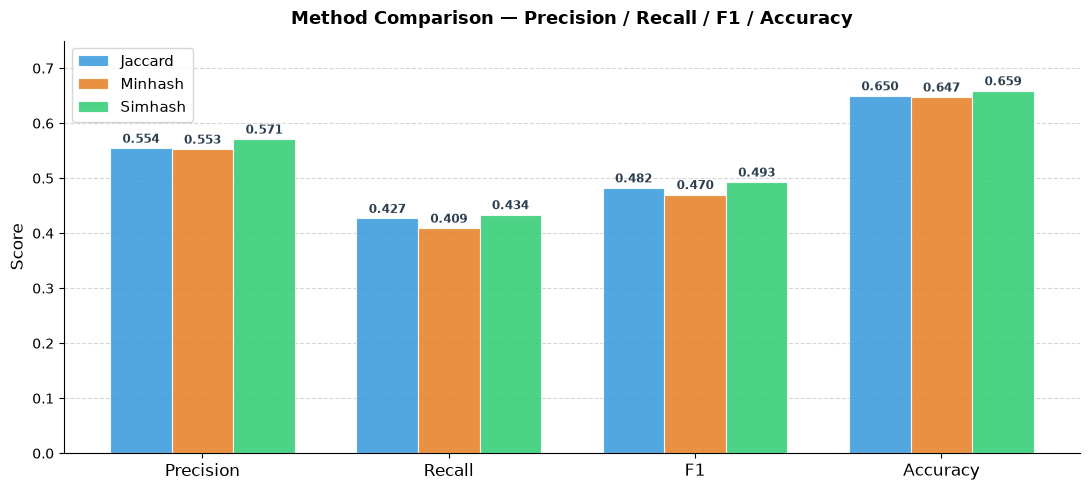

✓  Saved → outputs/method_comparison.png


In [8]:
import numpy as np

METRIC_COLS = ["Precision", "Recall", "F1", "Accuracy"]
method_names = df_show["Method"].tolist()

x = np.arange(len(METRIC_COLS))
width = 0.25
colors = ["#3498db", "#e67e22", "#2ecc71"]

fig, ax = plt.subplots(figsize=(11, 5))

for i, (method, color) in enumerate(zip(method_names, colors)):
    vals = df_show[df_show["Method"] == method][METRIC_COLS].values.flatten().tolist()
    bars = ax.bar(x + i * width, vals, width, label=method,
                  color=color, alpha=0.85, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=8.5, fontweight="bold", color="#2c3e50")

ax.set_xticks(x + width)
ax.set_xticklabels(METRIC_COLS, fontsize=12)
ax.set_ylim(0, 0.75)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Method Comparison — Precision / Recall / F1 / Accuracy",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(OUTPUTS / "method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved → outputs/method_comparison.png")
